In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from tensorflow.keras.utils import image_dataset_from_directory

I0000 00:00:1783821872.990743   13944 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# old_data = '../data/Driver Drowsiness Dataset (DDD)'
# split_data = '../data/split_data'
# splitfolders.ratio(old_data, output=split_data, seed=42, ratio=(0.8, 0.125, 0.075), group_prefix=None)

In [2]:
BATCH_SIZE = 128
IMG_SIZE = (128, 128)

train_dataset = image_dataset_from_directory(
      '../data/split_data/train',
      shuffle=True,
      batch_size=BATCH_SIZE,
      image_size=IMG_SIZE,
      seed=42
  )

validation_dataset = image_dataset_from_directory(
    '../data/split_data/val',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

test_dataset = image_dataset_from_directory(
    '../data/split_data/test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

Found 33434 files belonging to 2 classes.


I0000 00:00:1783822128.061608   13944 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5491 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1060 6GB, pci bus id: 0000:01:00.0, compute capability: 6.1


Found 5223 files belonging to 2 classes.
Found 3136 files belonging to 2 classes.


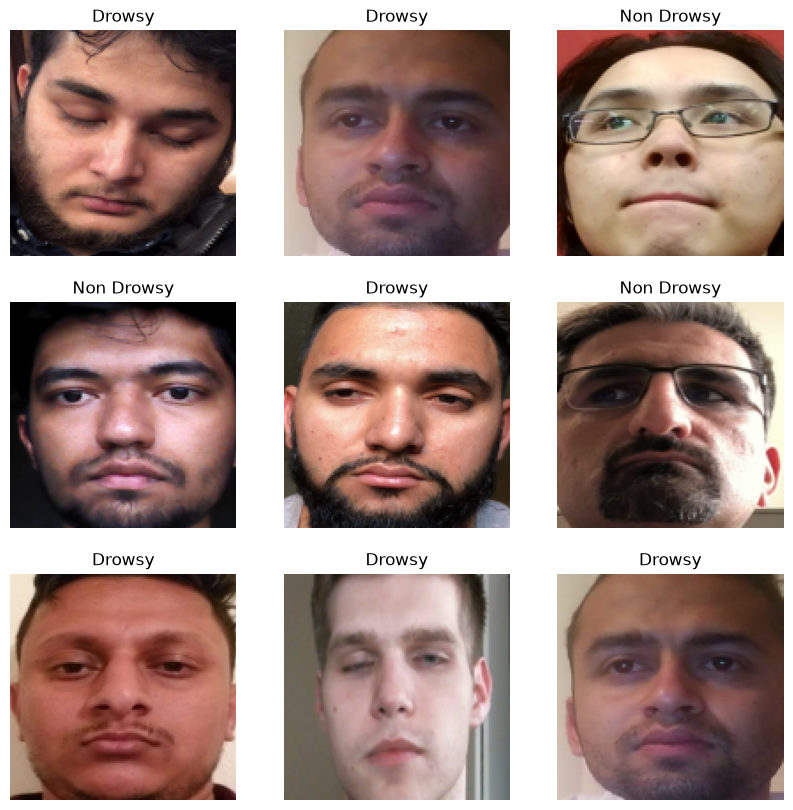

In [3]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [5]:
model = Sequential([
    Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3), kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(16, activation='relu', 
          kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])


/home/luke/ready-alert/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,801 (26.57 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 112 (448.00 B)

In [12]:
import tensorflow as tf
tf.config.optimizer.set_experimental_options({"layout_optimizer": False})
tf.keras.backend.clear_session()
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


I0000 00:00:1783822562.302547   14186 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3795__.59
W0000 00:00:1783822562.418501   14186 autotuner.cc:555] No reference output found even though buffer checking was requested while autotuning
W0000 00:00:1783822572.420116   14186 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 260.00MiB (rounded to 272634880)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1783822572.420217   14186 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1783822572.420226   14186 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 52, Chunks in use: 51. 13.0KiB allocated for chunks. 12.8KiB in use in bin. 1.7KiB client-requested in use in bin.
I0000 00:00:1783822572.420240   14186 bfc_allocator.cc:1056] Bin 

InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/luke/ready-alert/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/luke/ready-alert/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/luke/ready-alert/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/luke/ready-alert/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/luke/.pyenv/versions/3.11.15/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/home/luke/.pyenv/versions/3.11.15/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/home/luke/.pyenv/versions/3.11.15/lib/python3.11/asyncio/events.py", line 84, in 

In [20]:
model.evaluate(test_dataset)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9928 - loss: 0.3008


[0.28933185338974, 0.9891581535339355]

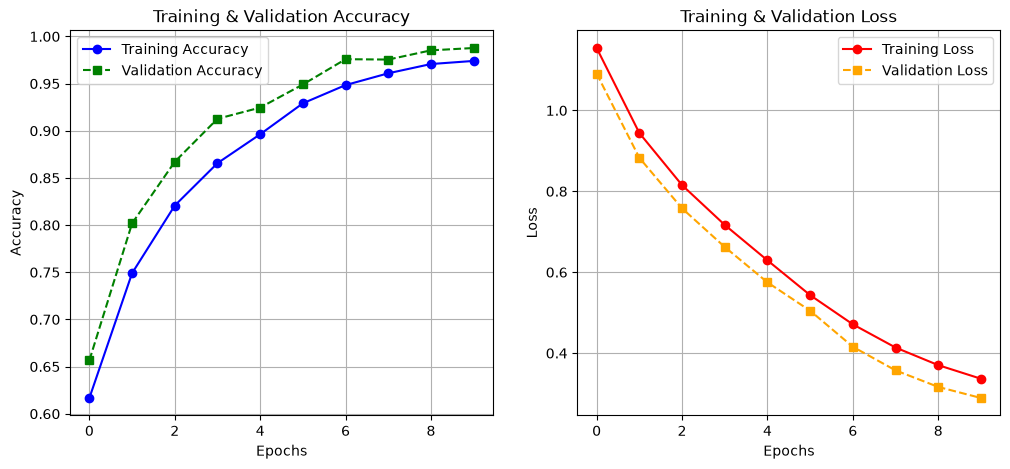

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", color="blue", marker="o", linestyle="-")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="green", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", color="red", marker="o", linestyle="-")
plt.plot(epochs_range, val_loss, label="Validation Loss", color="orange", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)

plt.show()

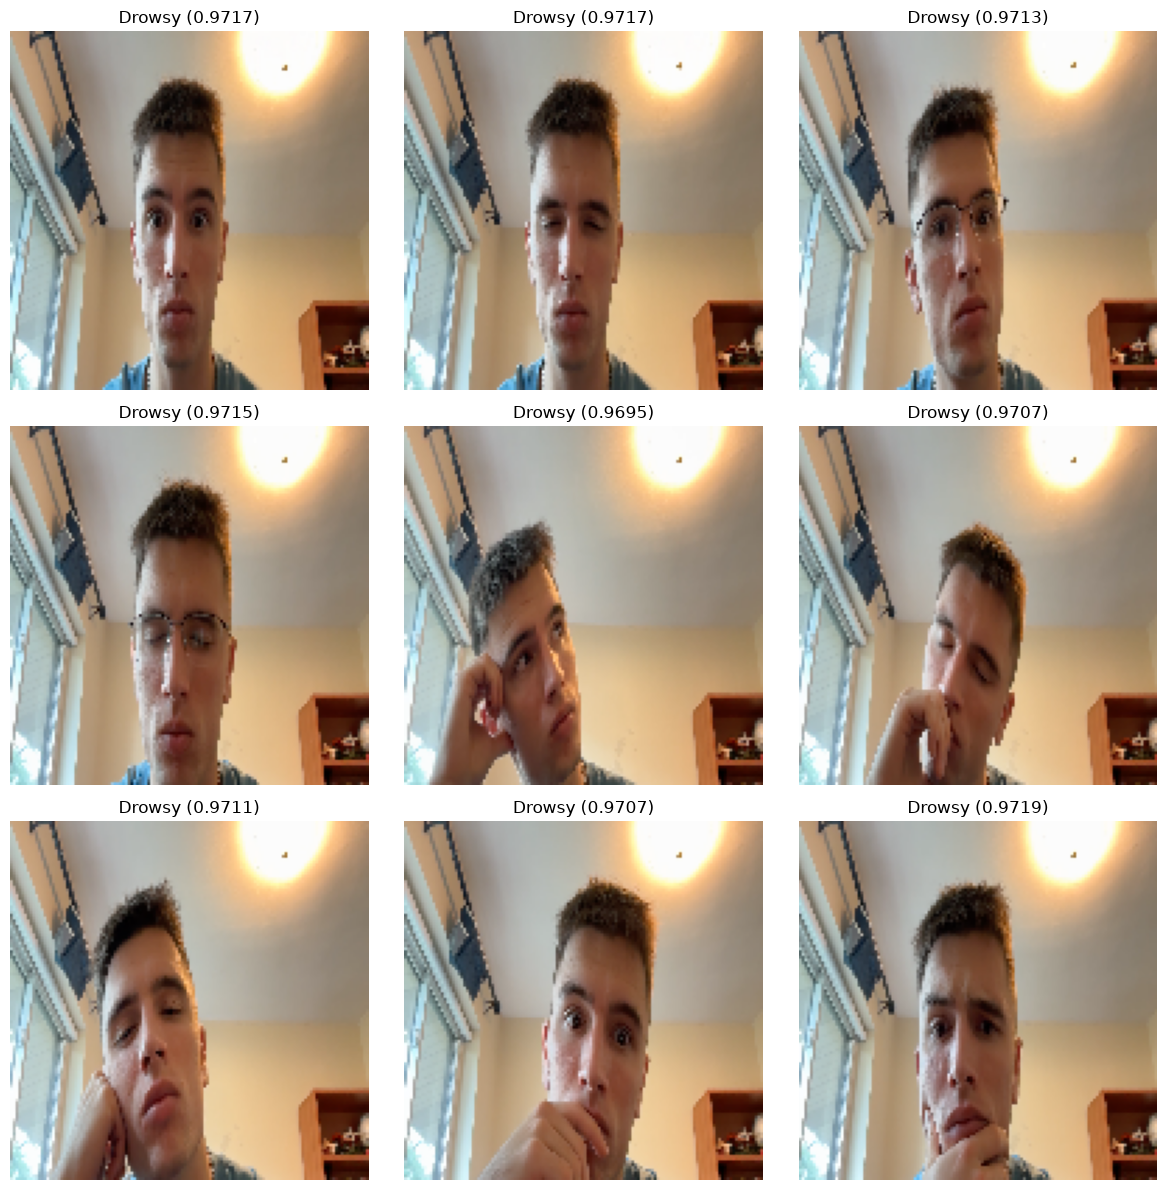

In [22]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

selfie_dir = '../data/selfies'
selfie_paths = sorted([
    os.path.join(selfie_dir, f)
    for f in os.listdir(selfie_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

class_names = test_dataset.class_names  # e.g. ['Drowsy', 'Non Drowsy']

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    return img, np.expand_dims(img_array, axis=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, path in enumerate(selfie_paths[:9]):
    img, img_array = preprocess_image(path)
    pred = model.predict(img_array, verbose=0)[0][0]
    class_idx = 1 if pred > 0.5 else 0
    label = class_names[class_idx]
    confidence = pred if class_idx == 1 else 1 - pred

    axes[i].imshow(img)
    axes[i].set_title(f"{label} ({confidence:.4f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [23]:
num_images = 15

test_dataset.reset()
images, true_labels = next(test_dataset)

images = images[:num_images]
true_labels = true_labels[:num_images]

predictions = model.predict(images)

class_indices = test_dataset.class_indices
class_names = {v: k for k, v in class_indices.items()}

rows = (num_images + 4) // 5
cols = min(num_images, 5)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_images > 1 else [axes]

for i in range(num_images):
    img = images[i]
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_label} ({confidence:.4f})")
    axes[i].axis('off')


for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Predictions for displayed images:")
for i in range(num_images):
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    print(f"Image {i+1}: Predicted Class: {pred_label}, Confidence: {confidence:.4f}")

AttributeError: '_PrefetchDataset' object has no attribute 'reset'